# Persistent Homology for Large Scale Structure (PHLSS)
## Comprehensive Guide: Theory, Implementation, and Applications

**Authors:** Matteo Biagetti and Alex Cole  
**Reference:** [The Persistence of Large Scale Structure I: Primordial non-Gaussianity](https://arxiv.org/abs/2009.04819)  
**Public Release:** v1.0

---

## Table of Contents
1. Introduction to Persistent Homology
2. Large Scale Structure & Cosmology
3. Mathematical Theory
4. Implementation Architecture
5. Workflow & Usage
6. Code Components Analysis
7. Practical Examples

## 1. Introduction to Persistent Homology

### What is Persistent Homology?

Persistent Homology is a method from **Topological Data Analysis (TDA)** that studies the **topological features** of point clouds across multiple scales.

Key concepts:
- **Homology**: Studies hole-like structures in data (0-dim: components/clusters, 1-dim: loops/voids, 2-dim: cavities)
- **Persistence**: Tracks how long these features exist as scale parameter changes
- **Filtration**: Parametrized family of nested complexes at increasing scales

### Why It Matters for Cosmology

The large-scale structure of the universe exhibits:
- **Clusters** of dark matter halos (filaments, clusters, nodes)
- **Voids** between these structures
- **Topological structures** encoded in cosmological parameters

Persistent homology captures these features to:
1. Constrain cosmological parameters (e.g., primordial non-Gaussianity)
2. Extract scale-dependent information
3. Avoid relying only on two-point statistics (power spectrum)

## 2. Large Scale Structure & Cosmology

### Background

- **N-body simulations**: Evolve billions of dark matter particles from early universe to present day
- **Halo catalogs**: Extract self-bound structures (halos) representing galaxy clusters
- **Positions & Masses**: Halos have 3D spatial coordinates and mass estimates

### Box Geometry

The code operates on periodic cubic boxes:
- **Main box**: 2000 Mpc/h (comoving megaparsec/h) - full simulation volume
- **Sub-boxes**: 1000 Mpc/h - subdomain partitions for computational efficiency
- **Redshift**: Analysis at redshift z=1 (intermediate cosmic epoch)

### Halo Selection

```
Mass range: 9.189×10^12 to 10^20 Msun/h
Total halos per subbox: 252,321
Subsampling: For computational tractability
```

## 3. Mathematical Theory

### 3.1 Simplicial Complexes

A simplicial complex is built from:
- **0-simplices (vertices)**: Individual points (halos)
- **1-simplices (edges)**: Connections between pairs of points
- **2-simplices (triangles)**: Connections between triples
- **3-simplices (tetrahedra)**: Connections between quadruples

**Alpha Complex**: Vertices connected if within distance r (Voronoi-based)
$$\text{Alpha complex} = \{\text{simplices from Delaunay triangulation within radius }r\}$$

### 3.2 Filtration Methods

#### Method 0: Alpha Filtration
Connect points based on **Euclidean distance**
$$\alpha_r = \{(i,j) : |x_i - x_j| < r\}$$

#### Method 1: Sublevel Filtration
Based on field values (cubical complex)
$$\text{Filtration based on height function values}$$

#### Method 2: Alpha-DTM Filtration
Combines alpha complex with **Distance-To-Measure (DTM)**:
$$\text{DTM}_m(x) = \sqrt{\frac{1}{k} \sum_{i=1}^{k} d_i(x)^2}$$
where $d_i(x)$ is distance to i-th nearest neighbor, $k = \lfloor m \cdot N \rfloor$

#### Method 3: Alpha-DTM with Length-DTM Mixing
Enhanced version combining:
- **Density information** (DTM at query points)
- **Edge weighting** (distance-dependent filtration values)

Edge filtration value:
$$\text{filt}(e_{ij}) = \begin{cases}
\sqrt{\frac{((f_i + f_j)^2 + d^2) \cdot ((f_i - f_j)^2 + d^2)}{4d^2}} & \text{if } p=2 \\
\frac{f_i + f_j + d}{2} & \text{if } p=1 \\
\max(f_i, f_j, d/2) & \text{if } p=\infty
\end{cases}$$
where $f_i, f_j$ are DTM values and $d$ is edge length.

### 3.3 Homology & Persistence

**Persistent Homology** tracks topology across scales:

$$H_p(\text{Complex}_\alpha) = \text{p-th homology group at scale }\alpha$$

For each feature (cycle):
- **Birth** ($b$): Scale where feature appears
- **Death** ($d$): Scale where feature merges/disappears
- **Persistence** ($p = d - b$): Lifetime of feature

**Interpretation**:
- **High persistence**: Robust topological feature (signal)
- **Low persistence**: Noise

### 3.4 Persistence Diagrams

Graphically represent persistence as (birth, death) points:
- Points far from diagonal: strong, persistent features
- Points near diagonal: weak, short-lived features

Three types by dimension:
- **H₀** (0-dimensional): Connected components/clusters
- **H₁** (1-dimensional): Holes/loops (void structure)
- **H₂** (2-dimensional): Cavities (enclosed regions)

## 4. Implementation Architecture

### 4.1 Project Structure

```
persistent_homology_lss/
├── Code/
│   ├── main.py              # Entry point & workflow orchestration
│   ├── param.py             # Global parameters & configuration
│   ├── user.py              # Command-line argument parsing
│   ├── pdiagram.py          # Persistence diagram computation
│   ├── pimages.py           # Persistence image generation
│   ├── fclaux.py            # Auxiliary functions (I/O, statistics)
│   └── DataReading/
│       └── readcatalogs.py  # Halo catalog loading (multiple formats)
├── Utils/
│   ├── genBounds/           # Bounds computation for statistics
│   ├── massBinner/          # Mass binning utilities
│   └── subBoxer/            # Sub-box extraction & analysis
├── Scripts/
│   ├── python_script.sh     # Local execution script
│   └── python_script_cartesius.sh  # HPC/SLURM script
└── Output/                  # Results directory
```

### 4.2 Key Classes

#### `DIAG` (pdiagram.py)
**Purpose**: Compute persistence diagrams from halo catalog

**Main methods**:
- `__init__`: Initialize with data, split into sub-boxes
- `parallelPD()`: Parallel computation across sub-boxes
- `computeSavePDalpha()`: Alpha filtration method
- `computeSavePDalphaDTM()`: Alpha-DTM filtration method
- `AlphaWeightedFiltration()`: DTM-weighted edge values
- `DTM()`: Distance-to-measure computation
- `Filtration_value()`: Complex edge weight calculation

**Output**: Persistence diagrams saved as CSV files with format:
```
dimension, birth, death
0, 0.5, 1.2
1, 0.3, 0.8
...
```

#### `IMAG` (pimages.py)
**Purpose**: Convert persistence diagrams to persistence images (2D images)

**Main methods**:
- `parallelPI()`: Parallel computation across sub-boxes
- `PI()`: Kernel density estimate of persistence diagram
- `V()`: 1D persistence image (death axis)
- `H()`: 1D persistence image (birth axis)
- `VH()`: 1D persistence image (persistence axis: death - birth)
- `Betti()`: Betti curve computation
- `calcSavePI()`: Calculate and save persistence image

**Output**: 2D arrays (images) that can be used as ML features

### 4.3 Data Flow Pipeline

```
Halo Catalog
        ↓
   readcatalogs.readcats()
        ↓
   Halo Data Array [Mass, X, Y, Z]
        ↓
   DIAG.__init__()  ← Partition into sub-boxes
        ↓
   parallelPD()    ← Parallel computation
        ↓
   Filtration Method  (Choose: alpha, sublevel, alpha-DTM, alpha-DTM+mix)
        ↓
   GUDHI Library  ← Simplex tree & persistence computation
        ↓
   Persistence Diagrams  [dim, birth, death]
        ↓
   saveBounds()   ← Compute bounds for statistics
        ↓
   IMAG.__init__()  ← Initialize image computation
        ↓
   parallelPI()    ← Compute images in parallel
        ↓
   PI() / V() / H() / VH() / Betti()  ← Statistical functions
        ↓
   Persistence Images  [2D arrays]
        ↓
   Machine Learning Models  (classifier, feature extractor)
```

## 5. Workflow & Usage

### 5.1 Parameter Configuration

Edit `param.py` to configure:

| Parameter | Default | Description |
|-----------|---------|-------------|
| `cat` | 1 | Catalog type (1=Rockstar, 2=Minerva, 3=Flagship) |
| `box` | 2000 | Box size in Mpc/h |
| `smallbox` | 1000 | Sub-box size in Mpc/h |
| `z` | 1 | Redshift |
| `mmin` | 9.189e12 | Minimum halo mass in M☉/h |
| `mmax` | 1e20 | Maximum halo mass in M☉/h |
| `method` | 3 | Filtration method (0-3) |
| `nhalo` | 252321 | Halos per sub-box |
| `thresh` | 1.3 | Outlier threshold |

### 5.2 Command-Line Arguments

```bash
python main.py \
  --hfile <halo_catalog_path> \
  --pd True \
  --pdfile <output_pd_path> \
  --pi True \
  --npool <num_processors> \
  --cut <persistence_cut> \
  --boundsName <bounds_file>
```

**Arguments**:
- `--hfile`: Path to halo catalog (required)
- `--pd`: Compute persistence diagrams (True/False)
- `--pdfile`: Output/input persistence diagram file (required)
- `--pi`: Compute persistence images (True/False)
- `--npool`: Number of parallel processors (default: 2)
- `--cut`: Minimum persistence threshold (default: 0)
- `--boundsName`: Bounds file for statistics (default: '0')
- `--arrayjob`: Enable SLURM array job mode (for HPC)
- `--onedim`: Compute 1D functions (advanced)

### 5.3 Example Execution

#### Basic Example: Test Dataset

```bash
cd Code
python main.py \
  --hfile ../TestData/out_z2_nosub_M200b_20p.list \
  --pd True \
  --pdfile ../Output/Subsampling/PD/test_alphaDTM_ \
  --pi True \
  --npool 4
```

#### Full-Scale Simulation

```bash
python main.py \
  --hfile /path/to/full/halo/catalog.list \
  --pd True \
  --pdfile Output/PD/full_sim_run1_ \
  --pi True \
  --npool 16 \
  --boundsName Output/bounds_run1.txt
```

#### HPC Submission (SLURM)

```bash
sbatch Scripts/python_script_cartesius.sh
```

## 6. Code Components Analysis

### 6.1 Main Entry Point (`main.py`)

**Flow**:
1. Parse command-line arguments via `user.parse_arguments()`
2. Load halo catalog with `readcat.readcats()`
3. Filter halos by mass
4. If `--arrayjob`, modify filenames for SLURM array tasks
5. If `--pd True`, compute persistence diagrams via `DIAG` class
6. Compute bounds file for statistical analysis
7. If `--pi True`, compute persistence images via `IMAG` class

### 6.2 Catalog Reading (`DataReading/readcatalogs.py`)

**Supported formats**:
- **Type 1 (Rockstar)**: Plain text, columns = [Mass, X, Y, Z]
- **Type 2 (Minerva)**: Binary format with structured array
- **Type 3 (Flagship)**: Parquet format with log-mass extraction

**Output**: Numpy array shape (N_halos, 4) with [Mass, X, Y, Z]

### 6.3 Persistence Diagram Computation

**Key process**:
1. Split box into 8×8×8 = 512 sub-boxes (for 2000 Mpc/h with 1000 Mpc/h sub-boxes)
2. For each sub-box:
   - Extract halos within boundaries
   - Subsample to `nhalo` = 252,321 halos per sub-box
   - Build simplicial complex using GUDHI
   - Compute persistence (algorithm: Zomorodian-Carlsson)
   - Save results as CSV
3. Parallelize across processors using `parmap`

### 6.4 Distance-To-Measure (DTM) Implementation

```python
def DTM(X, query_pts, m):
    '''Compute distance-to-measure function'''
    N_tot = X.shape[0]
    k = int(np.floor(m * N_tot)) + 1
    
    # Build KD-tree for efficient nearest neighbor search
    kdt = KDTree(X, leaf_size=30, metric='euclidean')
    
    # Query k-nearest neighbors
    NN_Dist, NN = kdt.query(query_pts, k, return_distance=True)
    
    # Compute DTM
    DTM_result = np.sqrt(np.sum(NN_Dist * NN_Dist, axis=1) / (k-1))
    
    return DTM_result
```

**Intuition**: DTM estimates local density. Dense regions = small DTM, sparse regions = large DTM.

### 6.5 Persistence Image Computation

**Persistence Image (PI)**: Convert persistence diagram to 2D image

$$\text{PI}(x,y) = \int \rho(b, p) \cdot K(x,y,b,p) \, db \, dp$$

where:
- $\rho(b, p)$: Point weights (persistence values)
- $K$: Kernel (epanechnikov, gaussian, etc.)
- $x,y$: Grid coordinates

**Implementation in code**:
- Use kernel density estimation (KDE) with bandwidth $\sigma$
- Grid resolution: 30×30 default
- Weight by persistence value

### 6.6 Auxiliary Functions (`fclaux.py`)

**`loadfile(fname)`**
- Parse text-based halo catalog
- Extract mass and 3D position

**`savePD(diag, filename)`**
- Convert GUDHI persistence output to CSV
- Format: [dimension, birth, death]
- Skip features with birth = death (trivial features)

**`cleanPD(pd, cut, power)`**
- Transform coordinates: (birth, death) → (birth, persistence)
- Apply power-law rescaling: $\text{value} \to \text{value}^p$
- Filter by persistence threshold
- Separate by dimension (H₀, H₁, H₂)

**Purpose of rescaling**: Emphasize different scales depending on cosmic analysis

## 7. Practical Examples

### 7.1 Understanding the Workflow

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Example 1: Create synthetic halo catalog
# Real catalog format: [Mass, X, Y, Z]

np.random.seed(42)

# Create synthetic halos
n_halos = 1000
masses = np.random.exponential(scale=1e13, size=n_halos) + 1e12  # Log-normal-like
positions = np.random.uniform(0, 2000, (n_halos, 3))  # Within 2000 Mpc/h box

catalog = np.column_stack([masses, positions])
print(f"Synthetic Catalog Shape: {catalog.shape}")
print(f"First 5 halos (Mass, X, Y, Z):\n{catalog[:5]}")
print(f"\nMass range: {catalog[:,0].min():.2e} to {catalog[:,0].max():.2e} Msun/h")
print(f"Position range: 0 to 2000 Mpc/h")

Synthetic Catalog Shape: (1000, 4)
First 5 halos (Mass, X, Y, Z):
[[5.69268090e+12 3.70265858e+02 1.08380189e+03 1.74589167e+03]
 [3.11012143e+13 1.46444977e+03 1.61312230e+03 1.31756673e+03]
 [1.41674569e+13 1.38455313e+03 1.69839130e+03 4.99336018e+02]
 [1.01294255e+13 9.78849927e+02 4.42418884e+02 1.97533602e+03]
 [2.69624870e+12 1.88811868e+03 7.88536227e+01 1.41115035e+03]]

Mass range: 1.05e+12 to 8.27e+13 Msun/h
Position range: 0 to 2000 Mpc/h


### 7.2 Understanding Persistence Diagrams

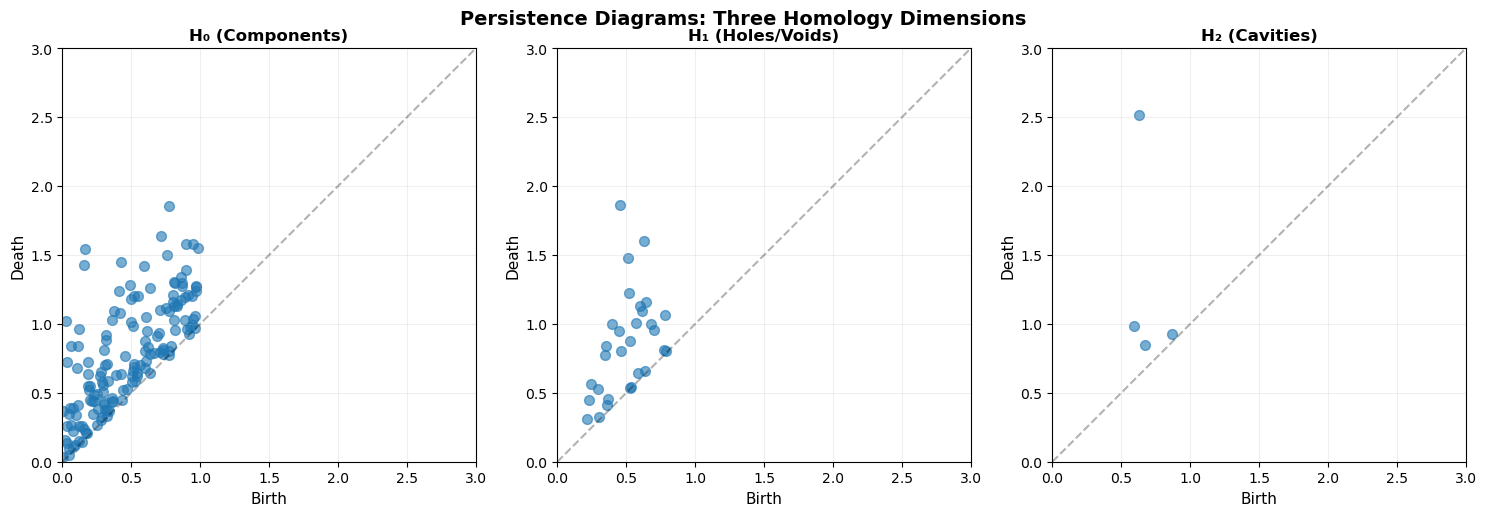

H₀ Persistence: mean=0.307, std=0.275
H₁ Persistence: mean=0.360, std=0.327
H₂ Persistence: mean=1.022, std=1.028


In [2]:
# Example 2: Synthetic persistence diagram
# Real output from DIAG class: CSV file with [dimension, birth, death]

# Create synthetic persistence diagram
np.random.seed(42)

# H0 (connected components) - generally more features
h0_birth = np.random.uniform(0, 1, 150)
h0_death = h0_birth + np.random.exponential(0.3, 150)
h0_points = np.column_stack([h0_birth, h0_death])

# H1 (holes/voids) - fewer features, generally larger persistence
h1_birth = np.random.uniform(0.2, 0.8, 30)
h1_death = h1_birth + np.random.exponential(0.5, 30)
h1_points = np.column_stack([h1_birth, h1_death])

# H2 (cavities) - rare features
h2_birth = np.random.uniform(0.4, 0.9, 5)
h2_death = h2_birth + np.random.exponential(0.8, 5)
h2_points = np.column_stack([h2_birth, h2_death])

# Plot persistence diagrams
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

max_val = 3
for ax, (points, title) in zip(axes, [(h0_points, 'H₀ (Components)'), 
                                        (h1_points, 'H₁ (Holes/Voids)'),
                                        (h2_points, 'H₂ (Cavities)')]):
    # Plot diagonal (trivial features)
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Diagonal')
    
    # Plot points
    ax.scatter(points[:, 0], points[:, 1], alpha=0.6, s=50)
    
    # Labels
    ax.set_xlabel('Birth', fontsize=11)
    ax.set_ylabel('Death', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.set_aspect('equal')
    ax.grid(alpha=0.2)

plt.suptitle('Persistence Diagrams: Three Homology Dimensions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Compute persistence
persistence_h0 = h0_death - h0_birth
print(f"H₀ Persistence: mean={persistence_h0.mean():.3f}, std={persistence_h0.std():.3f}")
print(f"H₁ Persistence: mean={(h1_death-h1_birth).mean():.3f}, std={(h1_death-h1_birth).std():.3f}")
print(f"H₂ Persistence: mean={(h2_death-h2_birth).mean():.3f}, std={(h2_death-h2_birth).std():.3f}")

### 7.3 Understanding Persistence Images

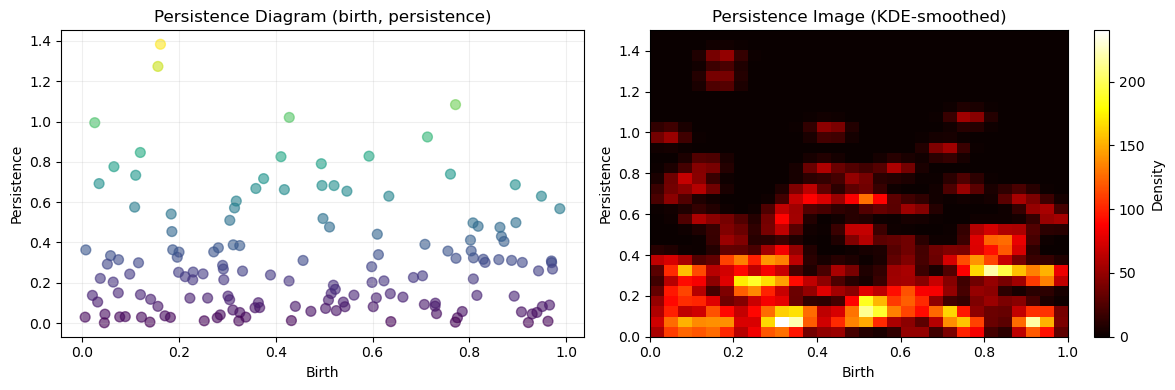

Persistence Image Shape: (30, 30)
Can be flattened to feature vector of size 900 for ML


In [3]:
from scipy.stats import gaussian_kde

# Example 3: Convert persistence diagram to persistence image

# Use H0 points as example
persistence = h0_death - h0_birth
pd_coords = np.column_stack([h0_birth, persistence])  # (birth, persistence) coordinates

# Create grid
grid_res = 30
birth_range = np.linspace(0, 1, grid_res)
pers_range = np.linspace(0, 1.5, grid_res)

# Compute 2D KDE
kde = gaussian_kde(pd_coords.T, bw_method=0.1)

# Evaluate on grid
birth_grid, pers_grid = np.meshgrid(birth_range, pers_range)
positions = np.vstack([birth_grid.ravel(), pers_grid.ravel()])
density = kde(positions).reshape(birth_grid.shape)

# Weight by persistence
pi_image = density * np.sum(persistence)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original diagram
axes[0].scatter(h0_birth, persistence, c=persistence, cmap='viridis', s=50, alpha=0.6)
axes[0].set_xlabel('Birth')
axes[0].set_ylabel('Persistence')
axes[0].set_title('Persistence Diagram (birth, persistence)')
axes[0].grid(alpha=0.2)

# Persistence image
im = axes[1].imshow(pi_image, extent=[0, 1, 0, 1.5], origin='lower', cmap='hot', aspect='auto')
axes[1].set_xlabel('Birth')
axes[1].set_ylabel('Persistence')
axes[1].set_title('Persistence Image (KDE-smoothed)')
plt.colorbar(im, ax=axes[1], label='Density')

plt.tight_layout()
plt.show()

print(f"Persistence Image Shape: {pi_image.shape}")
print(f"Can be flattened to feature vector of size {pi_image.size} for ML")

### 7.4 Distance-To-Measure (DTM) Visualization

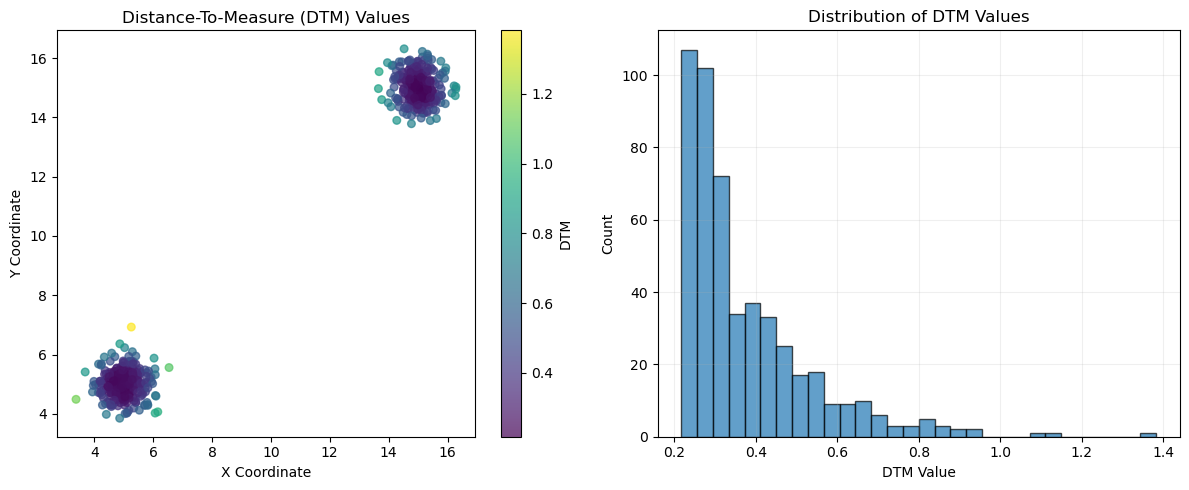

DTM Statistics:
  Min: 0.2168
  Max: 1.3825
  Mean: 0.3741

Interpretation:
  - Dense clusters (low DTM): represent high-density regions
  - Void regions (high DTM): represent sparse regions


In [6]:
from sklearn.neighbors import KDTree

# Example 4: DTM computation and visualization

# Create 2D point cloud (easier to visualize)
np.random.seed(42)
n_points = 500

# Create clusters
cluster1 = np.random.normal([5, 5], scale=0.5, size=(250, 2))
cluster2 = np.random.normal([15, 15], scale=0.5, size=(250, 2))
points = np.vstack([cluster1, cluster2])

# Compute DTM at each point
m = 0.1  # Use 10% of points for k-NN
k = int(np.floor(m * len(points))) + 1

kdt = KDTree(points, leaf_size=30)
distances, indices = kdt.query(points, k)
dtm_values = np.sqrt(np.sum(distances[:, 1:] ** 2, axis=1) / (k - 1))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# DTM values
scatter1 = axes[0].scatter(points[:, 0], points[:, 1], c=dtm_values, cmap='viridis', s=30, alpha=0.7)
axes[0].set_xlabel('X Coordinate')
axes[0].set_ylabel('Y Coordinate')
axes[0].set_title('Distance-To-Measure (DTM) Values')
plt.colorbar(scatter1, ax=axes[0], label='DTM')

# DTM distribution
axes[1].hist(dtm_values, bins=30, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('DTM Value')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of DTM Values')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"DTM Statistics:")
print(f"  Min: {dtm_values.min():.4f}")
print(f"  Max: {dtm_values.max():.4f}")
print(f"  Mean: {dtm_values.mean():.4f}")
print(f"\nInterpretation:")
print(f"  - Dense clusters (low DTM): represent high-density regions")
print(f"  - Void regions (high DTM): represent sparse regions")

### 7.5 Sub-box Partitioning

Box Configuration:
  Main box: 2000 × 2000 × 2000 Mpc/h
  Sub-box size: 1000 × 1000 × 1000 Mpc/h
  Sub-box grid: 2 × 2 × 2
  Total sub-boxes: 8

With 4 processors: ~2 sub-boxes per processor


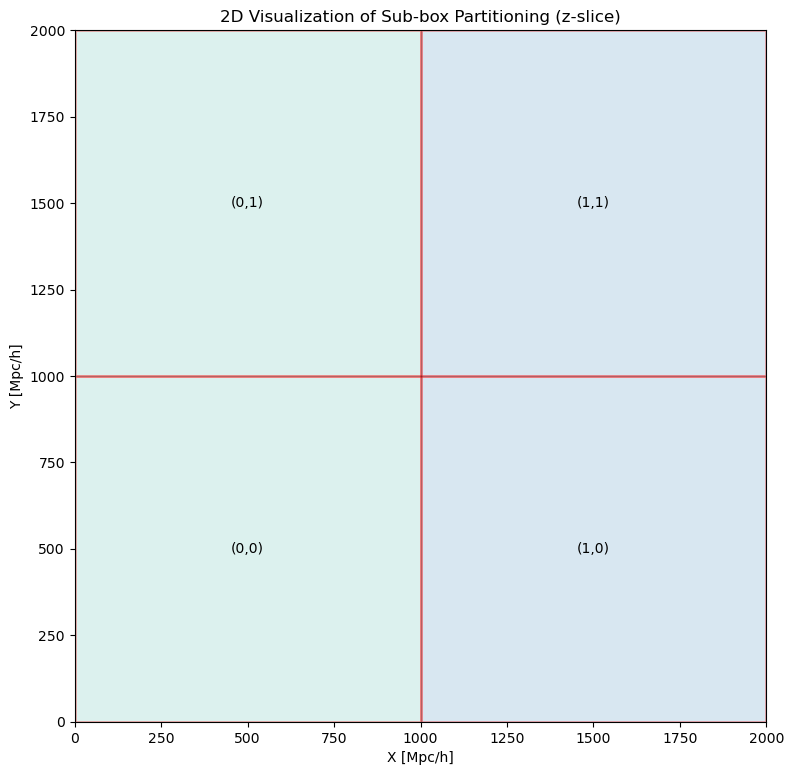

In [7]:
# Example 5: Understanding box partitioning for parallel computation

# Parameters
box_size = 2000  # Mpc/h
sub_box_size = 1000  # Mpc/h

# Calculate grid
nsub = int(box_size / sub_box_size)
print(f"Box Configuration:")
print(f"  Main box: {box_size} × {box_size} × {box_size} Mpc/h")
print(f"  Sub-box size: {sub_box_size} × {sub_box_size} × {sub_box_size} Mpc/h")
print(f"  Sub-box grid: {nsub} × {nsub} × {nsub}")
print(f"  Total sub-boxes: {nsub**3}")
print(f"\nWith {4} processors: ~{nsub**3/4:.0f} sub-boxes per processor")

# Visualize 2D slice
fig, ax = plt.subplots(figsize=(8, 8))

# Draw grid
for i in range(nsub + 1):
    ax.axhline(y=i * sub_box_size, color='k', linewidth=0.5, alpha=0.3)
    ax.axvline(x=i * sub_box_size, color='k', linewidth=0.5, alpha=0.3)

# Color some sub-boxes
colors = plt.cm.Set3(np.linspace(0, 1, 4))
for idx, (i, color) in enumerate(zip(range(0, 2), colors)):
    for j in range(2):
        rect = plt.Rectangle((i * sub_box_size, j * sub_box_size), 
                            sub_box_size, sub_box_size,
                            facecolor=color, alpha=0.3, edgecolor='red', linewidth=2)
        ax.add_patch(rect)
        ax.text(i * sub_box_size + sub_box_size/2, j * sub_box_size + sub_box_size/2,
               f'({i},{j})', ha='center', va='center', fontsize=10)

ax.set_xlim(0, box_size)
ax.set_ylim(0, box_size)
ax.set_aspect('equal')
ax.set_xlabel('X [Mpc/h]')
ax.set_ylabel('Y [Mpc/h]')
ax.set_title(f'2D Visualization of Sub-box Partitioning (z-slice)')
plt.tight_layout()
plt.show()

### 7.6 Four Filtration Methods Comparison

In [8]:
# Example 6: Conceptual comparison of four filtration methods

methods_info = {
    'Method 0: Alpha Filtration': {
        'desc': 'Pure geometric distance-based',
        'pros': ['Simple', 'Standard', 'Fast'],
        'cons': ['No density information', 'Sensitive to noise'],
        'edge_rule': 'Euclidean distance'
    },
    'Method 1: Sublevel Filtration': {
        'desc': 'Height function-based (cubical complex)',
        'pros': ['Captures field structure', 'Handles non-Euclidean'],
        'cons': ['Discrete (cubical)', 'Resolution-dependent'],
        'edge_rule': 'Field value (height)'
    },
    'Method 2: Alpha-DTM': {
        'desc': 'Alpha complex weighted by density',
        'pros': ['Noise robust', 'Density-aware'],
        'cons': ['Computationally expensive', 'Parameter-dependent'],
        'edge_rule': 'max(DTM_i, DTM_j)'
    },
    'Method 3: Alpha-DTM + Length-DTM': {
        'desc': 'Enhanced density weighting with edge distance',
        'pros': ['Most noise robust', 'Best for LSS'],
        'cons': ['Slowest', 'Complex computation'],
        'edge_rule': 'Mixed DTM-based formula'
    }
}

for method, info in methods_info.items():
    print(f"\n{'='*70}")
    print(f"{method}")
    print(f"{'='*70}")
    print(f"Description: {info['desc']}")
    print(f"Pros: {', '.join(info['pros'])}")
    print(f"Cons: {', '.join(info['cons'])}")
    print(f"Edge Rule: {info['edge_rule']}")


Method 0: Alpha Filtration
Description: Pure geometric distance-based
Pros: Simple, Standard, Fast
Cons: No density information, Sensitive to noise
Edge Rule: Euclidean distance

Method 1: Sublevel Filtration
Description: Height function-based (cubical complex)
Pros: Captures field structure, Handles non-Euclidean
Cons: Discrete (cubical), Resolution-dependent
Edge Rule: Field value (height)

Method 2: Alpha-DTM
Description: Alpha complex weighted by density
Pros: Noise robust, Density-aware
Cons: Computationally expensive, Parameter-dependent
Edge Rule: max(DTM_i, DTM_j)

Method 3: Alpha-DTM + Length-DTM
Description: Enhanced density weighting with edge distance
Pros: Most noise robust, Best for LSS
Cons: Slowest, Complex computation
Edge Rule: Mixed DTM-based formula


## 8. Advanced Topics

### 8.1 Computational Complexity

| Operation | Complexity | Bottleneck |
|-----------|-----------|------------|
| KD-tree construction | O(n log n) | Large n |
| k-NN search | O(k log n) | Fast |
| Delaunay triangulation | O(n log n) → O(n^⌈d/2⌉) | Scales badly in high-d |
| DTM computation | O(n log n) | Manageable |
| Persistence computation | O(n^α) | Depends on complex size |
| KDE (persistence images) | O(grid² × n) | High resolution → slow |

**Optimization strategies**:
- Subtract-boxes reduce dimensionality
- Random subsampling (252K halos per box)
- Parallel processing via `parmap`
- GUDHI's optimized C++ backend

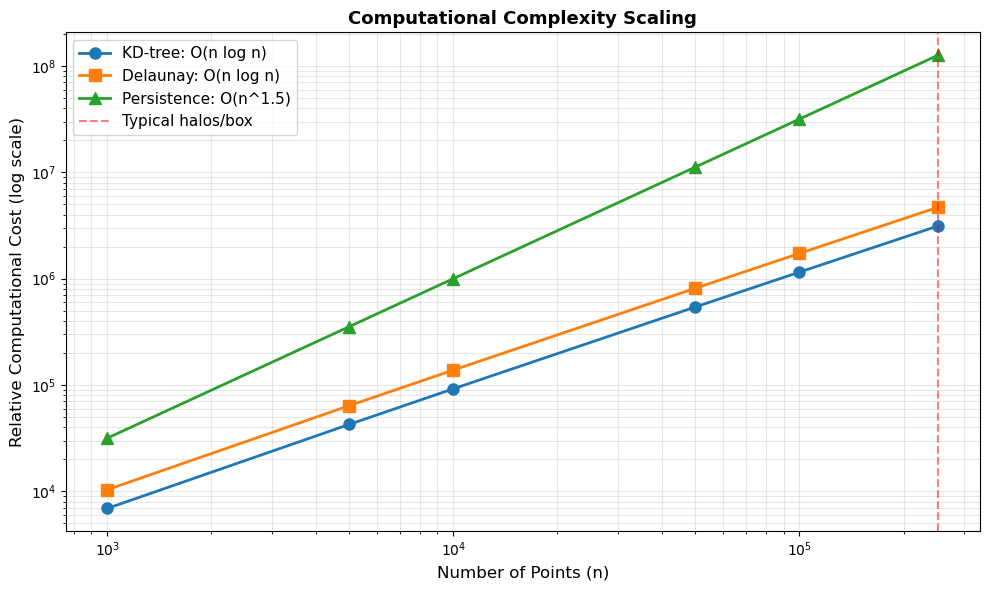

For 252,321 halos per sub-box:
  Estimated KD-tree operations: 3.14e+06
  With 8³ = 512 sub-boxes + parallelization on 16 cores
  Total boxes per core: 32.0 = 32
  Rough wall-clock time per core: hours (actual varies with tuning)


In [9]:
# Example 7: Computational cost estimation

import matplotlib.pyplot as plt

# Estimate computational scaling
n_points = np.array([1000, 5000, 10000, 50000, 100000, 252321])

# Approximate complexities (log scale)
kdtree_cost = n_points * np.log(n_points)
delaunay_cost = n_points * np.log(n_points) * 1.5  # Cubic in 3D
persistence_cost = n_points ** 1.5  # Approximate

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(n_points, kdtree_cost, 'o-', label='KD-tree: O(n log n)', linewidth=2, markersize=8)
ax.loglog(n_points, delaunay_cost, 's-', label='Delaunay: O(n log n)', linewidth=2, markersize=8)
ax.loglog(n_points, persistence_cost, '^-', label='Persistence: O(n^1.5)', linewidth=2, markersize=8)

# Mark typical values
ax.axvline(x=252321, color='red', linestyle='--', alpha=0.5, label='Typical halos/box')

ax.set_xlabel('Number of Points (n)', fontsize=12)
ax.set_ylabel('Relative Computational Cost (log scale)', fontsize=12)
ax.set_title('Computational Complexity Scaling', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print(f"For {252321:,} halos per sub-box:")
print(f"  Estimated KD-tree operations: {kdtree_cost[5]:.2e}")
print(f"  With 8³ = 512 sub-boxes + parallelization on 16 cores")
print(f"  Total boxes per core: {512/16} = 32")
print(f"  Rough wall-clock time per core: hours (actual varies with tuning)")

### 8.2 Cosmological Interpretation

**Why persistence homology is valuable for cosmology**:

1. **Primordial non-Gaussianity (PNG)**
   - Traditional power spectrum only captures Gaussian statistics
   - PNG leaves imprints on topological features
   - Persistence homology captures these signatures

2. **Scale-dependent information**
   - Birth scale: When structure forms
   - Death scale: When it merges
   - Different scales → different physics

3. **Complementary to other methods**
   - Power spectrum: 2-point statistics
   - Bispectrum: 3-point statistics  
   - Persistent homology: **Topology** - independent information

4. **Mass selection effects**
   - Mass threshold changes halo population
   - Affects topological features
   - Can constrain halo mass function

## Summary & Best Practices

### Key Takeaways

1. **PHLSS** applies topological data analysis to cosmology
2. **Workflow**: Halo catalog → Persistence diagrams → Persistence images → ML
3. **Four methods** with increasing noise robustness (Method 3 best)
4. **Parallel processing** essential for large catalogs (512 sub-boxes)
5. **Parameter tuning** affects physics extraction

### Tuning Recommendations

```python
# param.py settings
method = 3                    # Use most robust method
nhalo = 252321               # Good balance computational/statistics
mmin = 9.189e12              # Massive halos (more robust)
thresh = 1.3                 # Outlier removal
smallbox = 1000              # Balance parallel efficiency

# Command line
npool = min(32, n_cores)     # Max parallelization
cut = 0.01                   # Minimal persistence threshold
```

### Output Interpretation

- **Persistence diagrams**: Raw topological features (birth, death) by dimension
- **Persistence images**: Machine-learning-ready 2D feature images
- **Betti curves**: 1D summaries of topological evolution
- **Statistics files**: Bounds and outlier information for further analysis

## References & Further Reading

### Primary Literature
- Biagetti, M. & Cole, A. (2020). *The Persistence of Large Scale Structure I: Primordial non-Gaussianity*. [arXiv:2009.04819](https://arxiv.org/abs/2009.04819)
- N-body simulations: [Cosmos simulation suite](https://mbiagetti.gitlab.io/cosmos/nbody/eos/)

### Topological Data Analysis
- Edelsbrunner, H. & Harer, J. (2010). *Computational Topology: An Introduction*. AMS
- Adams, H., et al. (2017). *Persistence Images: A Stable Vector Representation of Persistent Homology*. [arXiv:1505.04087](https://arxiv.org/abs/1505.04087)
- Chazal, F., et al. (2016). *Statistical topological data analysis using persistence landscapes*. JMLR

### Software & Libraries
- **GUDHI**: [Geometry Understanding in Higher Dimensions](http://gudhi.gforge.inria.fr/) - Simplex tree & persistence computation
- **scikit-learn**: KD-trees, KDE, machine learning
- **parmap**: Parallel mapping for easy parallelization
- **NumPy/SciPy**: Scientific computing foundations